# TU257 - Assignment 1

#### Student 1: Pedro Batlouni
#### Student 2: Paulo Soares 

#### Group Num= 3
#### Problem Set= Problem Set 2  – Supermarket Marketing Campaign 

#### Analysis Approach: This notebook documents the full analysis process. 
#### Each step includes:
#### - what was done,
#### - why the step was necessary,
#### - what insights or outcomes were obtained.
#### The goal is not only to show the technical steps, but also to explain the reasoning behind the analysis and how each stage connects, from data exploration and preparation to model building, evaluation, and final recommendations.

# Step 1 - Importing Libraries

On this project, we are importing some libraries to make the analyzes of this project. They are Pandas, Numpy, Matplotlib and sklearn.
Pandas allows us to handle the different data types found in the organics datase. It will allow us to store different data types to a grid allowing us to perform multiple analyzes.

On other side, Numpy is a fundamental package tool to for scientific computing analyzes an it is the numerical python engine.

Matplotlib provides plotting capabilities, enabling us to create visualizations of the data for easier interpretation.

Scikit-learn (sklearn): a comprehensive machine learning library in Python, providing tools for:  
  - Data preparation: train_test_split for splitting datasets into training and testing sets, StandardScaler for feature scaling.  
  - Modeling: various classifiers such as LogisticRegression, DecisionTreeClassifier, RandomForestClassifier, KNeighborsClassifier, and GaussianNB.  
  - Evaluation: metrics and functions including accuracy_score, confusion_matrix, classification_report, roc_curve, and roc_auc_score to assess model performance.

In [2]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, cross_val_score


# Step 2 - Importing the Data Set

Importing the dataset usign "r" as the helper. This is done due to python having backslash as an escape character.

The use of "r" at the begining, will help python to avoid a misinterpretation while reading the given path.

The reason is because the path is coming from a windowns file and it has many backslash on it. By taking this step, it will require less adjustments to the path.

The below piece of code below is asking pandas to read and show the csv file by following its location to the file name that is, organics.csv.

In [1]:
df = pd.read_csv(r"C:\\Users\\batlo")

NameError: name 'pd' is not defined

In [4]:
# Display the first rows of the dataset to make sure it was correctly loaded
print('print first rows')
df.head()

print first rows


,CUSTID,GENDER,DOB,EDATE,AGE,AGEGRP1,AGEGRP2,TV_REG,NGROUP,NEIGHBORHOOD,LCDATE,ORGANICS,BILL,REGION,CLASS,ORGYN,AFFL,LTIME
0,140,U,16/09/2021,23/02/1998,76,60-80,70-80,Wales & West,C,16.0,07/11/1994,0,16000.00,Midlands,Gold,0,10,4
1,620,U,12/02/1949,23/02/1998,49,40-60,40-50,Wales & West,D,35.0,04/06/1993,0,6000.00,Midlands,Gold,0,4,5
2,868,F,27/11/2027,23/02/1998,70,60-80,70-80,Wales & West,D,27.0,02/08/1990,1,0.02,Midlands,Silver,1,5,8
3,1120,M,10/04/1932,23/02/1998,65,60-80,60-70,Midlands,F,51.0,01/07/1991,1,0.01,Midlands,Tin,1,10,7
4,2313,F,21/05/2029,23/02/1998,68,60-80,60-70,Midlands,A,4.0,01/03/1990,0,0.01,Midlands,Tin,0,11,8


# Step 3 - Data Exploration

For the initial data exploration, we will work with some attributes and methods in few steps below to have an understanding of the structre of the dataset like:

- Numbers of rows and columns.
- Data Types.
- Missing Values.

### Checking the Number of rows and columns by using "df.shape".

In [5]:
print('shape')
print ("Number of Rows:",df.shape[0])
print ("Number of Columns:",df.shape[1])
print ("Shape:",df.shape)

shape
Number of Rows: 22223
Number of Columns: 18
Shape: (22223, 18)


### Checking data type and missing values by using "df.info".

This step helps us on making some decisions as:

- Changing or not a data type,
- Dropping or filing a null values,
- Deleting or not a collum,
- Which areas should we make the first check steps as per checking the age, etc.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22223 entries, 0 to 22222
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   CUSTID        22223 non-null  int64  
 1   GENDER        19711 non-null  object 
 2   DOB           22223 non-null  object 
 3   EDATE         22223 non-null  object 
 4   AGE           22223 non-null  object 
 5   AGEGRP1       20715 non-null  object 
 6   AGEGRP2       20715 non-null  object 
 7   TV_REG        21758 non-null  object 
 8   NGROUP        21549 non-null  object 
 9   NEIGHBORHOOD  21549 non-null  float64
 10  LCDATE        22223 non-null  object 
 11  ORGANICS      22223 non-null  int64  
 12  BILL          22223 non-null  float64
 13  REGION        21758 non-null  object 
 14  CLASS         22223 non-null  object 
 15  ORGYN         22223 non-null  int64  
 16  AFFL          22223 non-null  object 
 17  LTIME         22223 non-null  object 
dtypes: float64(2), int64(3), o

### Showing Unique Values

This step is userful for identifying categorical variables

In [7]:
print('Number of Unique Values')
df.nunique()

Number of Unique Values


CUSTID          22223
GENDER              3
DOB             12868
EDATE               1
AGE                63
AGEGRP1             4
AGEGRP2             7
TV_REG             13
NGROUP              7
NEIGHBORHOOD       55
LCDATE           3535
ORGANICS            4
BILL             2606
REGION              5
CLASS               4
ORGYN               2
AFFL               34
LTIME              40
dtype: int64

### Checking Missing (null) Values

This step is one of the most important while doing the dataset preparation as by doing it we can:

- Prevent wrong statisttics results,
- Think about where to drop or to fill a column,
- Identify systematic errors if there is any,
- Avoid a Machine Learning to crash if they find missing values, etc.

In [8]:
print('Number of Missing Values')
df.isnull().sum()

Number of Missing Values


CUSTID             0
GENDER          2512
DOB                0
EDATE              0
AGE                0
AGEGRP1         1508
AGEGRP2         1508
TV_REG           465
NGROUP           674
NEIGHBORHOOD     674
LCDATE             0
ORGANICS           0
BILL               0
REGION           465
CLASS              0
ORGYN              0
AFFL               0
LTIME              0
dtype: int64

### Checking Portion of the Missing Values

The result of this step, will report the percentage of Missing Values. This is an important result to see which column is or is not relaiable. By mentioning that, any column that has 0% of missing values, are the ones that we will look at for our project. The ones that are >0, are the ones that we will have to make a decision in what to do.

In [9]:
print('Proportion of Missing Values')
print((df.isnull().sum() / len(df) * 100).round(2))

Proportion of Missing Values
CUSTID           0.00
GENDER          11.30
DOB              0.00
EDATE            0.00
AGE              0.00
AGEGRP1          6.79
AGEGRP2          6.79
TV_REG           2.09
NGROUP           3.03
NEIGHBORHOOD     3.03
LCDATE           0.00
ORGANICS         0.00
BILL             0.00
REGION           2.09
CLASS            0.00
ORGYN            0.00
AFFL             0.00
LTIME            0.00
dtype: float64


### Generating Summary Statistics.

By runing the code below, we will get a table that shows some important "caviars" to guide us on the next steps of this project.

In [10]:
# This piece of code set the display summary statistics to 2 decimal places as a way to facilitate the reading and interpretations of the results.

df.describe().style.format("{:.2f}")

,CUSTID,NEIGHBORHOOD,ORGANICS,BILL,ORGYN
count,22223.00,21549.00,22223.00,22223.00,22223.00
mean,26055403.44,27.19,0.29,4420.59,0.25
std,15074974.06,15.75,0.56,7559.05,0.43
min,140.00,1.00,0.00,0.01,0.00
25%,11694023.00,14.00,0.00,0.01,0.00
50%,28748786.00,27.00,0.00,2000.00,0.00
75%,37454019.50,38.00,0.00,6000.00,0.00
max,52856469.00,55.00,3.00,296313.85,1.00


The following analysis presents the purchases of organic products. It provides the frequency distribution of the "orgyn" column for buyers and non-buyers, where 1 represents buyers and 0 represents non-buyers.

In [11]:
print('Distribution of Organic Products as results, (1) for buyer and (0) for non-buyer')
df['ORGYN'].value_counts()

Distribution of Organic Products as results, (1) for buyer and (0) for non-buyer


ORGYN
0    16718
1     5505
Name: count, dtype: int64

In [12]:
print('Percentege of buyers of organic products. (1) = to buyers (0) = non-buyers')
(df['ORGYN'].value_counts(normalize=True) * 100).round(2)

Percentege of buyers of organic products. (1) = to buyers (0) = non-buyers


ORGYN
0    75.23
1    24.77
Name: proportion, dtype: float64

### Diplaying Portion Results in a Bar Plot

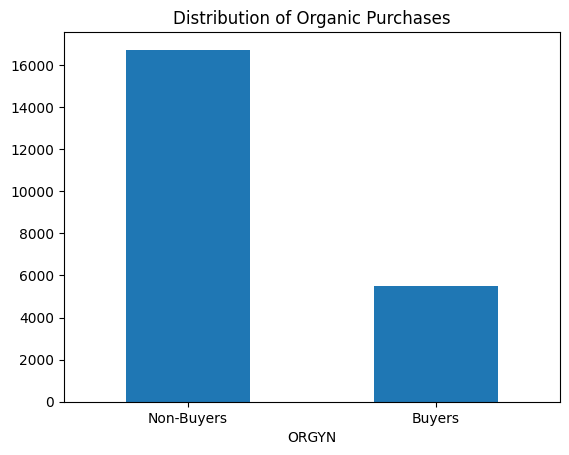

In [13]:
# Mapping values in the bar plot
df["ORGYN"].replace({0: 'Non-Buyers', 1: 'Buyers'}).value_counts().plot(kind='bar')
plt.title('Distribution of Organic Purchases')
plt.xticks(rotation=0)
plt.show()

### Gender and Organic Purchase Behaviour

This chart shows the distribution of organic product purchases by gender. The purpose of this analysis is to explore whether gender has an influence on the likelihood of purchasing organic products.

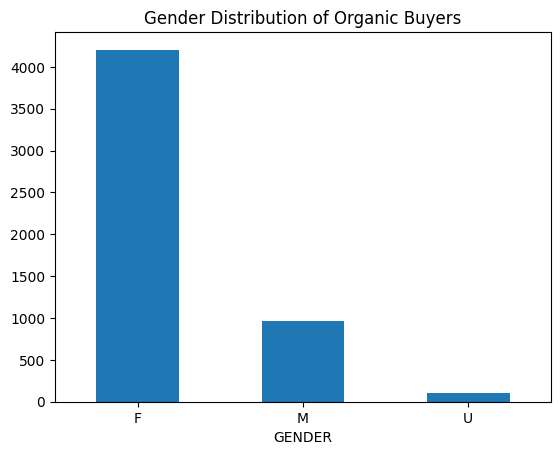

In [14]:
df[df["ORGYN"] == 1]["GENDER"].value_counts().plot(kind="bar")

plt.title("Gender Distribution of Organic Buyers")
plt.xticks(rotation=0)

plt.show()

### Displaying the Column Names

To display an overview of the columns that are in the dataset. This migth help on the decision making of which columns will be kept to present the results.

In [15]:
print('Column names')
df.columns

Column names


Index(['CUSTID', 'GENDER', 'DOB', 'EDATE', 'AGE', 'AGEGRP1', 'AGEGRP2',
       'TV_REG', 'NGROUP', 'NEIGHBORHOOD', 'LCDATE', 'ORGANICS', 'BILL',
       'REGION', 'CLASS', 'ORGYN', 'AFFL', 'LTIME'],
      dtype='object')

### The steps below, we are perfoming a data check/validation on the columns we believe that should be kept for a nice report result.

### Converting 'AGE' column to numeric and handling non-numeric values
 Rationale:
- The 'AGE' column should be numeric for analysis and modeling.
- Any non-numeric or missing entries are coerced to NaN and then filled with the median value.
- This ensures consistency, prevents errors during calculations, and preserves the overall distribution of the data.

In [16]:
df["AGE"] = pd.to_numeric(df["AGE"], errors='coerce')
df["AGE"] = df["AGE"].fillna(df["AGE"].median())

In [17]:
# Double check on bill columns as it can not have negative results as spending should never be negative.
df["BILL"].dtype
df["BILL"].describe()

count     22223.000000
mean       4420.590041
std        7559.047522
min           0.010000
25%           0.010000
50%        2000.000000
75%        6000.000000
max      296313.850000
Name: BILL, dtype: float64

### Converting 'AFFL' column to numeric and handling non-numeric values
 Rationale: the 'AFFL' column should be numeric for analysis and modeling. 
 Any non-numeric or missing entries are coerced to NaN and then filled with the median value. 
 This ensures consistency, prevents errors during calculations, and preserves the overall distribution of the data.

In [18]:
df["AFFL"] = pd.to_numeric(df["AFFL"], errors='coerce')
df["AFFL"] = df["AFFL"].fillna(df["AFFL"].median())

### Checking for null or blank values in categorical columns
 Rationale: columns like GENDER, AGEGRP1, AGEGRP2, TV_REG, NGROUP, REGION, NEIGHBORHOOD should not contain null or blank values
 because missing data can cause errors in modeling, analysis, and visualization. This validation step ensures that all blanks and nulls have been accounted for.

In [19]:
columns = ["GENDER","AGEGRP1","AGEGRP2","TV_REG","NGROUP","REGION","NEIGHBORHOOD","NGROUP"]
df[columns].isnull().sum()
df[columns].eq("").sum()

GENDER          0
AGEGRP1         0
AGEGRP2         0
TV_REG          0
NGROUP          0
REGION          0
NEIGHBORHOOD    0
NGROUP          0
dtype: int64

### Replacing blanks with 'Unknown' in categorical columns
 Rationale: columns like GENDER, AGEGRP1, AGEGRP2, TV_REG, NGROUP, REGION, NEIGHBORHOOD may contain blanks or null values.
 Replacing them with 'Unknown' ensures consistency, preserves all rows, and avoids errors in exploration, visualization, and downstream modeling.

In [20]:
columns = ["GENDER","AGEGRP1","AGEGRP2","TV_REG","NGROUP","REGION","NEIGHBORHOOD","NGROUP"]

for columns in columns:
    df[columns] = df[columns].replace("", "Unknown")
    df[columns] = df[columns].fillna("Unknown")

In [21]:
# Checking if there are the columns we need for the model we will present.

print('Column names')
df.columns

Column names


Index(['CUSTID', 'GENDER', 'DOB', 'EDATE', 'AGE', 'AGEGRP1', 'AGEGRP2',
       'TV_REG', 'NGROUP', 'NEIGHBORHOOD', 'LCDATE', 'ORGANICS', 'BILL',
       'REGION', 'CLASS', 'ORGYN', 'AFFL', 'LTIME'],
      dtype='object')

In [22]:
# Checking the dataframe after data cleasing.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22223 entries, 0 to 22222
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   CUSTID        22223 non-null  int64  
 1   GENDER        22223 non-null  object 
 2   DOB           22223 non-null  object 
 3   EDATE         22223 non-null  object 
 4   AGE           22223 non-null  float64
 5   AGEGRP1       22223 non-null  object 
 6   AGEGRP2       22223 non-null  object 
 7   TV_REG        22223 non-null  object 
 8   NGROUP        22223 non-null  object 
 9   NEIGHBORHOOD  22223 non-null  object 
 10  LCDATE        22223 non-null  object 
 11  ORGANICS      22223 non-null  int64  
 12  BILL          22223 non-null  float64
 13  REGION        22223 non-null  object 
 14  CLASS         22223 non-null  object 
 15  ORGYN         22223 non-null  int64  
 16  AFFL          22223 non-null  float64
 17  LTIME         22223 non-null  object 
dtypes: float64(3), int64(3), o

In [23]:
# Generating summary statistics after data cleasing.

df.describe().style.format("{:.2f}")

,CUSTID,AGE,ORGANICS,BILL,ORGYN,AFFL
count,22223.00,22223.00,22223.00,22223.00,22223.00,22223.00
mean,26055403.44,53.81,0.29,4420.59,0.25,8.68
std,15074974.06,12.75,0.56,7559.05,0.43,3.34
min,140.00,18.00,0.00,0.01,0.00,0.00
25%,11694023.00,45.00,0.00,0.01,0.00,6.00
50%,28748786.00,54.00,0.00,2000.00,0.00,8.00
75%,37454019.50,63.00,0.00,6000.00,0.00,10.00
max,52856469.00,79.00,3.00,296313.85,1.00,34.00


### Checking DOB correctness

 We want to verify if the dates of birth (DOB) are valid. This will help us decide whether to rely on the DOB column or the calculated Age. Below we calculate Age based on DOB only and check for any negative ages, which indicate errors in the DOB data.

In [24]:
# Convert DOB to datetime, assuming day/month/year format
df['DOB'] = pd.to_datetime(df['DOB'], dayfirst=True, errors='coerce') 

In [25]:
# Calculate Age in years
df['Age'] = (pd.Timestamp.today() - df['DOB']).dt.days//365

In [26]:
# Save CUSTID, DOB, and Age to a CSV for inspection
df[['CUSTID', 'DOB', 'AGE']].to_csv('cust_dob_age_check.csv', index=False)

In [27]:
# Filter for negative ages to identify incorrect DOBs
df_negative_age = df[df['Age'] < 0]

# Display rows with negative Age
df_negative_age[['CUSTID', 'DOB', 'Age']]

,CUSTID,DOB,Age
2,868,2027-11-27,-2
4,2313,2029-05-21,-4
16,11932,2027-08-09,-2
22,20478,2027-12-24,-2
37,45799,2026-11-10,-1
...,...,...,...
22174,52757525,2027-02-09,-1
22181,52768926,2027-03-22,-2
22188,52779553,2029-11-16,-4
22204,52804167,2028-07-31,-3


### Dropring Columns that we wont use in our project
 Rationale: columns like CUSTID, DOB, EDATE, LCDATE, ORGANICS do not provide predictive value, are redundant, or require transformations that are unnecessary for modeling. Removing them simplifies the dataset.
 Specific note on DOB: when inspecting the file, the dates appeared inconsistent; birth years did not match the reported ages, and some entries even had 2021 as birth year. This seems to be a system error, possibly from converting day/month/year to month/day/year. Therefore, we drop the DOB column rather than attempting to correct it.

In [28]:
df = df.drop(
    ["CUSTID", "DOB", "EDATE", "LCDATE", "ORGANICS"],
    axis=1
)

Plotting - Histogram Customer Age


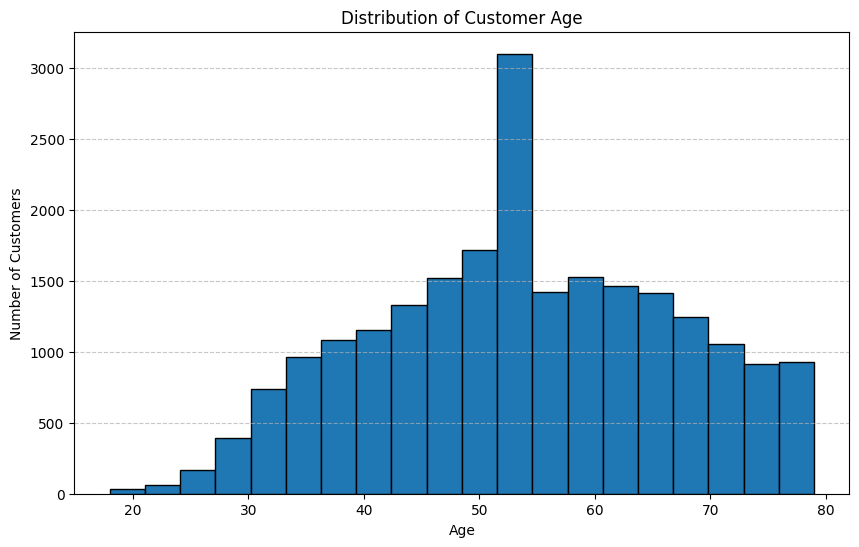

In [29]:
# Distribution of customer age after cleaning, fixing datatype and filing null/blank values.

print('Plotting - Histogram Customer Age')
plt.figure(figsize=(10,6))

plt.hist(df['AGE'], bins=20, edgecolor='black')

plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

### Age and Organic Product Purchases

 This histogram shows the age distribution of customers who purchased organic products. The objective is to identify whether certain age groups are more likely to buy organic products.

Plotting - Histogram Age Distribution of Organic Buyers


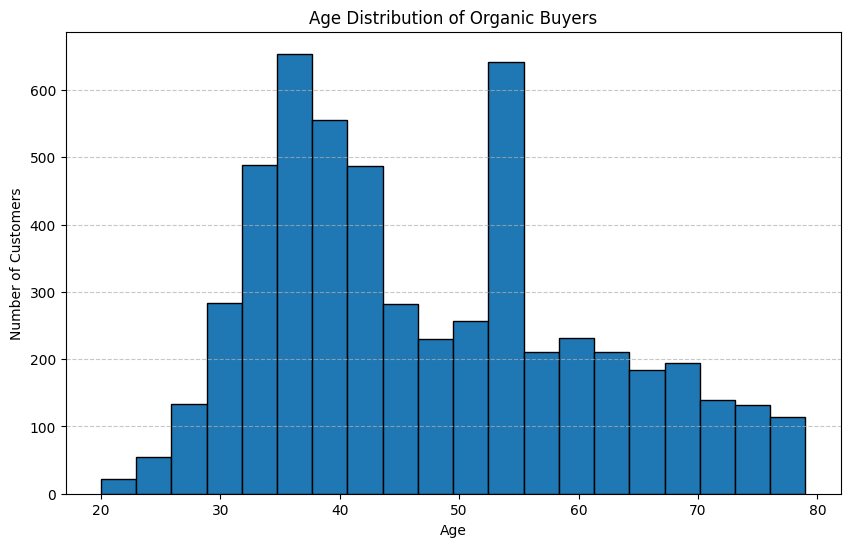

In [30]:
print('Plotting - Histogram Age Distribution of Organic Buyers')

# 1. Set the figure size to match (10x6)
plt.figure(figsize=(10, 6))

# 2. Add edgecolor and ensure bins=20 inside the plot call
df[df["ORGYN"] == 1]["AGE"].plot(kind="hist", bins=20, edgecolor='black')

# 3. Add titles and labels (matching the "Frequency" vs "Number of Customers" style)
plt.title("Age Distribution of Organic Buyers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

# 4. Add the horizontal dashed grid
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Plotting - Histogram Bill


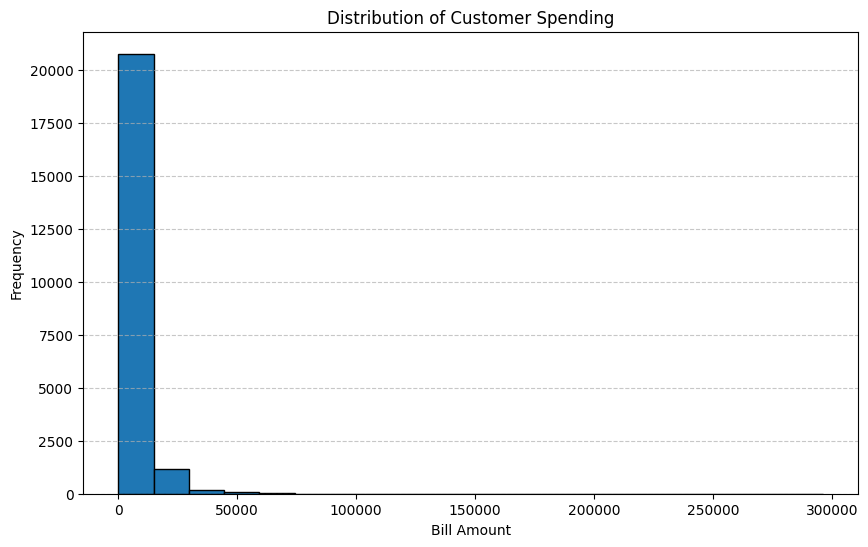

In [31]:
print('Plotting - Histogram Bill')
plt.figure(figsize=(10,6))

plt.hist(df['BILL'], bins=20, edgecolor='black')

plt.title("Distribution of Customer Spending")
plt.xlabel("Bill Amount")
plt.ylabel("Frequency")

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Plotting - Histogram Bill


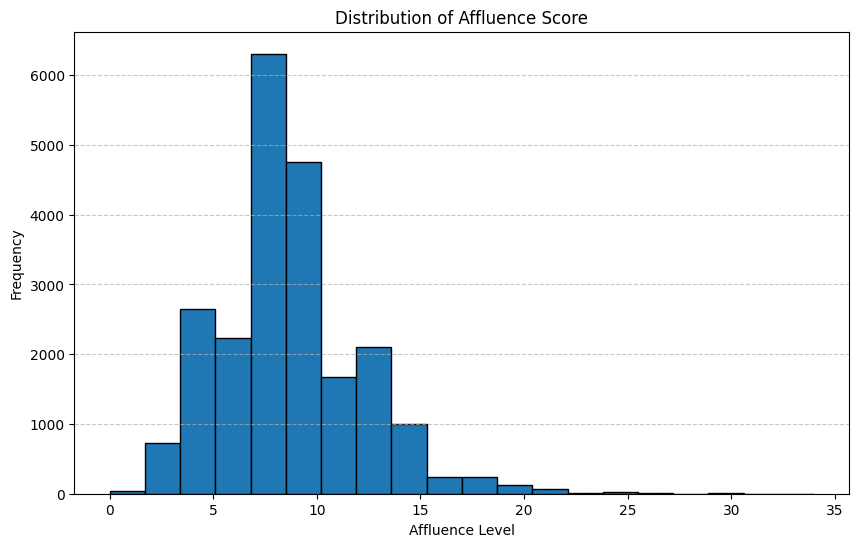

In [32]:
print('Plotting - Histogram Bill')
plt.figure(figsize=(10,6))

plt.hist(df['AFFL'], bins=20, edgecolor='black')

plt.title("Distribution of Affluence Score")
plt.xlabel("Affluence Level")
plt.ylabel("Frequency")

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

### Affluence and Organic Purchases

 This chart illustrates the distribution of affluence scores among customers who purchased organic products. The aim is to explore whether higher income levels are associated with organic product purchases.

Plotting - Histogram Affluence (Organic Buyers Only)


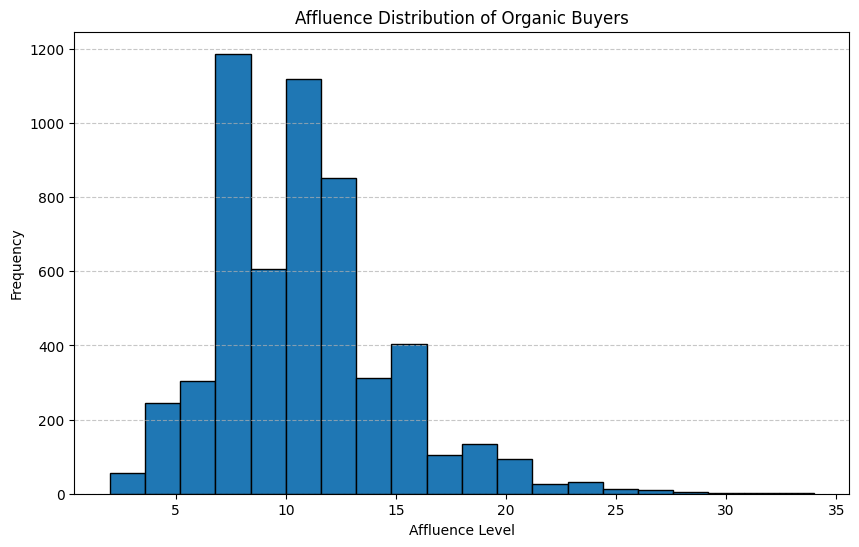

In [33]:
print('Plotting - Histogram Affluence (Organic Buyers Only)')

plt.figure(figsize=(10,6))

plt.hist(df[df["ORGYN"] == 1]['AFFL'], bins=20, edgecolor='black')

plt.title("Affluence Distribution of Organic Buyers")
plt.xlabel("Affluence Level")
plt.ylabel("Frequency")

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

### Affluence Level Behaviour

 Interestingly, customers with medium to low afflunce level show a higher probability of purchasing organic products. This may indicate that organic products attract newer or less established customers within the loyalty programme.

Plotting - Histogram Bill


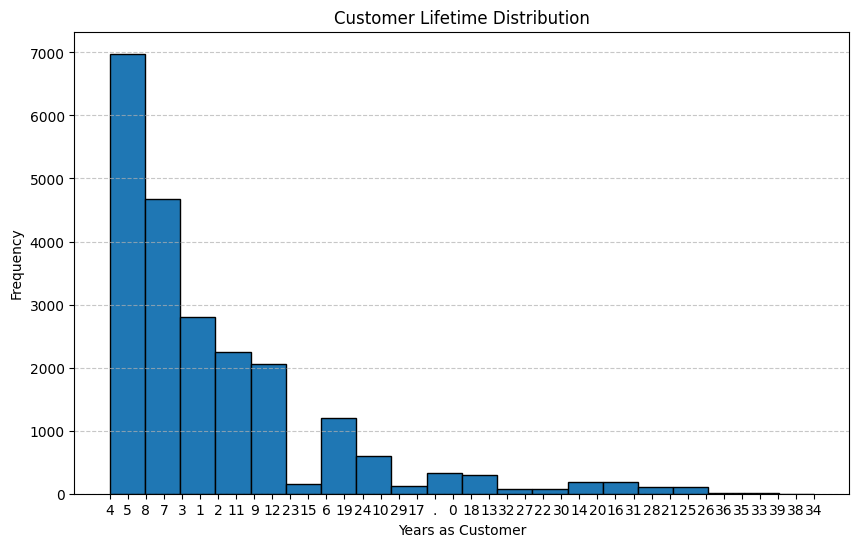

In [34]:
print('Plotting - Histogram Bill')
plt.figure(figsize=(10,6))

plt.hist(df['LTIME'], bins=20, edgecolor='black')

plt.title("Customer Lifetime Distribution")
plt.xlabel("Years as Customer")
plt.ylabel("Frequency")

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

### Lifetime and Organic Purchases.

Plotting - Histogram Bill


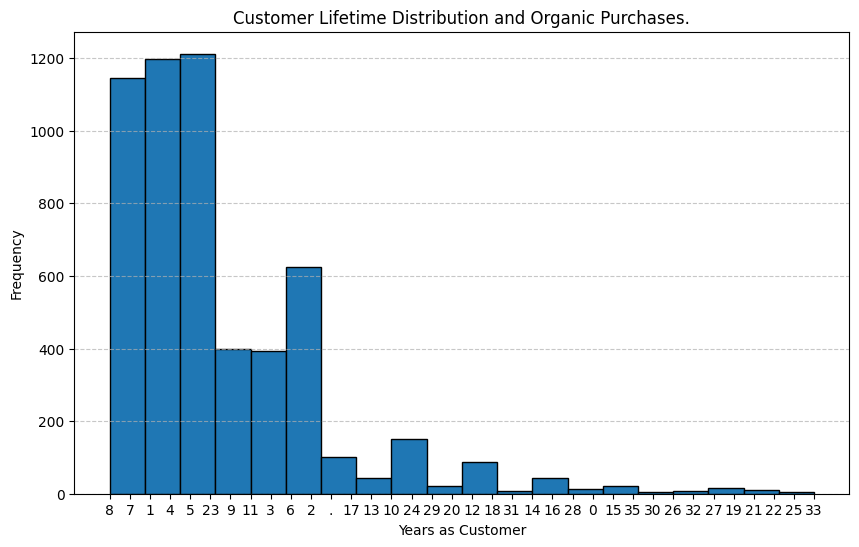

In [35]:
print('Plotting - Histogram Bill')
plt.figure(figsize=(10,6))

plt.hist(df[df["ORGYN"] == 1]['LTIME'], bins=20, edgecolor='black')

plt.title("Customer Lifetime Distribution and Organic Purchases.")
plt.xlabel("Years as Customer")
plt.ylabel("Frequency")

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

### Converting categorical columns to numeric using one-hot encoding
 Rationale:
- Many machine learning models require numeric inputs, so categorical columns must be transformed.
- pd.get_dummies converts each category into a separate binary column (0 or 1).
- drop_first=True removes the first category of each column to avoid multicollinearity and redundancy.
- This transformation ensures the dataset is ready for modeling while preserving all categorical information.

In [36]:
df = pd.get_dummies(df, drop_first=True)

# Step 4 - Data Insights Discovered so far

#### After exploring the dataset, we identified several columns that do not add predictive value or are redundant(removed in code cell 28):

 - Some categorical columns are redundant or provide little variability.
 - CUSTID contains only unique identifiers, so it cannot help predict buyer behavior(removed in code cell 28).
 - EDATE has the same value for all rows, offering no information for modeling(removed in code cell 28).
 - DOB is not directly usable by models, and we already have an 'age' column derived from it(feature engineered in code cells 24 and 25, removed in cell 27).
 - LCDATE contains dates that models cannot interpret meaningfully(removed in code cell 28).
 - ORGANICS is redundant because we focus on the ORGYN column to classify buyers vs non-buyers(ORGYN analysed in code cell 12, column removed in cell 28).
 These insights justify why these columns will be removed in the data cleaning and feature engineering step.
 By removing these columns early, we reduce noise, avoid misleading the model, and simplify downstream analysis and visualization.

#### Additionally, during preliminary preprocessing:

 - Blank or null values in categorical columns were replaced with 'Unknown' to preserve all rows and ensure models can use the data(handled in code cell 7).
 - Numeric columns such as AGE, BILL, and AFFL were converted to numeric types and missing/non-numeric values were filled with their median to maintain consistency and prevent calculation errors(implemented in code cells 18).
 - We have identified portions of missing values in some columns(code cells 8 and 9). Two of then with large amount as per 11.30% in column gender and AGEGRP1 and AGEGRP2 with 6.78% of missing values each. These columns had their rows filled as unknow and as the models wont read null values(code cell 20).
 - get_dumies have been added to an step above as it converts text column to binary columns making the dataset readable for the models that we will work with.
 - We have identifed an unbalenced buyers class where only 24.77% for the costumers buys organic products. This should be considered while evaluating the models later.
 - On the monetary column BILL, we might have a suggestion of varying levels of costumer buying power with the mean of roughly 4,420.59 and max of 29,613.85(analysed in code cell 17).

#### These insights and transformations provide a clear roadmap for Step 5 – Data Cleaning & Feature Engineering, ensuring the dataset is consistent, informative, and ready for predictive modeling.

 Typical organic buyer profile:

 - Female
 - Age 20–40
 - Low-Medium affluence score
 - Short Customer Lifetime 

# Step 5 - Data Cleaning & Feature Engineering

### Step 5 – Data Cleaning & Feature Engineering

 At this stage, the dataset is prepared for machine learning models. Based on the insights discovered during the exploration phase, several transformations are applied to improve data quality and usability.

 The objectives of this step are:

• Remove irrelevant or redundant features (implemented in code cell 28).  
• Ensure categorical variables are properly encoded (partially handled in code cell 20, and via get_dummies in code cell 36).  
• Validate data consistency (supported by preprocessing in code cells 8, 9, 16, 18 and 20).  
• Prepare features that can improve model performance(e.g. Age feature engineered in code cells 24)

 Feature Reduction: Several columns were removed because they either contained redundant information, incorrect values, or provided no predictive power for the target variable ORGYN(performed in code cell 23).

 Data Validation: Before building the models, additional validation checks were performed to ensure that:

• No unexpected missing values remain (validated after handling in code cells 7, 9 and 19). 
• Categorical columns contain valid categories  (standardised in code cell 19).
• Numeric columns fall within reasonable ranges(validated through preprocessing and summary statistics in code cells 15, 16 and 17).



# Step 6 - Data Preparation

 Machine learning models require the dataset to be divided into training and testing subsets. The dataset is therefore split into:

• Training set – used for the model to learn patterns
• Testing set – used to evaluate the model's predictive performance

 This approach ensures that the model is evaluated on unseen data, which helps measure how well it generalizes to new customers.

#### Train-Test Split: The dataset is split using the train_test_split function. Typically, 70–80% of the data is used for training and the remaining portion for testing. This prevents the model from simply memorizing the dataset and ensures a fair evaluation.

In [37]:
X = df.drop("ORGYN", axis=1)
y = df["ORGYN"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 7 - Creating the Models

 In this step, we will create and train multiple machine learning models to predict the target variable.  The models included are Logistic Regression, Decision Tree, Random Forest, K-Nearest Neighbors, and Gaussian Naive Bayes.  
 We will use the metrics previously imported (accuracy_score, confusion_matrix, classification_report, roc_curve, and roc_auc_score) to evaluate the performance of each model and compare their predictive ability.

In [38]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

results = {}

for name, model in models.items():
    
    if name in ["Logistic Regression","KNN"]:
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        
    acc = accuracy_score(y_test, pred)
    results[name] = acc
    
    print(name)
    print("Accuracy:", acc)
    print(confusion_matrix(y_test, pred))
    print(classification_report(y_test, pred))

Logistic Regression
Accuracy: 0.8128233970753656
[[3130  202]
 [ 630  483]]
              precision    recall  f1-score   support

           0       0.83      0.94      0.88      3332
           1       0.71      0.43      0.54      1113

    accuracy                           0.81      4445
   macro avg       0.77      0.69      0.71      4445
weighted avg       0.80      0.81      0.80      4445

Decision Tree
Accuracy: 0.7390326209223848
[[2757  575]
 [ 585  528]]
              precision    recall  f1-score   support

           0       0.82      0.83      0.83      3332
           1       0.48      0.47      0.48      1113

    accuracy                           0.74      4445
   macro avg       0.65      0.65      0.65      4445
weighted avg       0.74      0.74      0.74      4445

Random Forest
Accuracy: 0.8069741282339707
[[3121  211]
 [ 647  466]]
              precision    recall  f1-score   support

           0       0.83      0.94      0.88      3332
           1       0.

## Step 7 - Evaluating the Models

In [39]:
results_df = pd.DataFrame(results.items(), columns=['Model','Accuracy'])
results_df

,Model,Accuracy
0,Logistic Regression,0.812823
1,Decision Tree,0.739033
2,Random Forest,0.806974
3,KNN,0.750281
4,Naive Bayes,0.738583


### Results

#### Logistic Regression Results:

The Logistic Regression model achieved an accuracy of 0.81 on the test dataset.

This indicates that the model correctly predicts whether a customer is an organic buyer or non-buyer in approximately 81% of cases.

Logistic Regression is a relatively simple and interpretable model, which makes it useful as a baseline model for comparison with more complex algorithms.

### Decision Tree Results

The Decision Tree model achieved an accuracy of 0.74.

This performance is lower than the Logistic Regression model, suggesting that the decision tree may be overfitting the training data or not generalizing as effectively to the test dataset.

### Random Forest Results

The Random Forest model achieved an accuracy of 0.81, matching the performance of the Logistic Regression model.

Random Forest combines multiple decision trees, which often improves stability and reduces overfitting. In this case, the model performs well in predicting organic purchasing behaviour.

### K-Nearest Neighbors Results

The K-Nearest Neighbors (KNN) model achieved an accuracy of 0.75.

While the model performs reasonably well, it does not outperform Logistic Regression or Random Forest. This suggests that the relationship between the variables and organic purchasing behaviour may not be strongly driven by proximity-based patterns in the feature space.


Model Accuracy Comparison


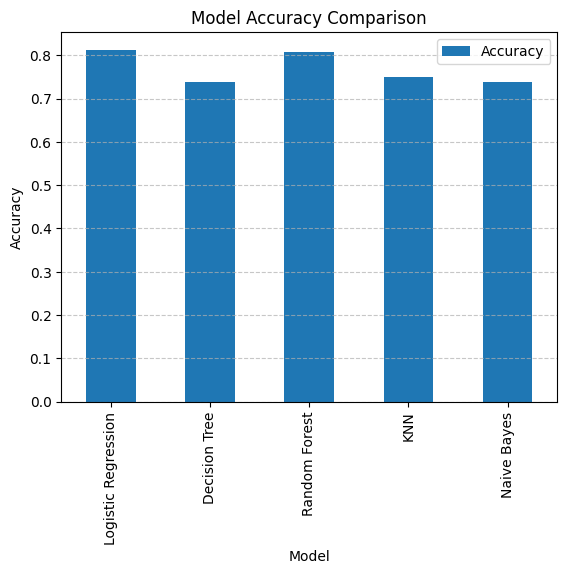

In [40]:
# This piece of code is displaying a comparison of the results between the 5 used models to evaluate the dataframe.

print('Model Accuracy Comparison')

results_df.plot(x='Model', y='Accuracy', kind='bar')

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

### ROC Curve and AUC

To evaluate the classification performance of the Random Forest model, the ROC Curve and AUC score were used.

The ROC curve illustrates the trade-off between the True Positive Rate and the False Positive Rate across different classification thresholds. A curve closer to the top-left corner indicates better model performance. The AUC (Area Under the Curve) provides a single metric summarizing this performance. A value closer to 1.0 indicates strong discriminative ability, while a value near 0.5 suggests the model performs no better than random guessing.

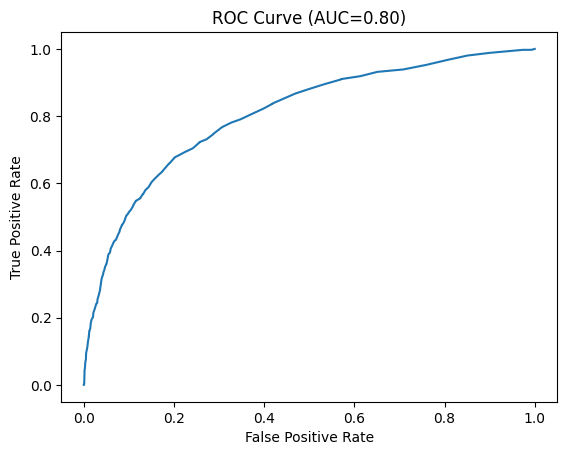

In [41]:
rfc = RandomForestClassifier()
rfc.fit(X_train, y_train)

probs = rfc.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, probs)
auc = roc_auc_score(y_test, probs)

plt.plot(fpr, tpr)
plt.title(f"ROC Curve (AUC={auc:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In this case, the model achieved an AUC score of {auc:.2f}, indicating that it has a reasonable ability to distinguish between customers who purchase organic products and those who do not.

In [42]:
# Average cross validation

scores = cross_val_score(RandomForestClassifier(), X, y, cv=10)
print("Average Cross Validation Accuracy:", scores.mean())

Average Cross Validation Accuracy: 0.8075421104863523


### Cross-Validation

To ensure the model's performance is reliable and not dependent on a single data split, 10-fold cross-validation was applied. This result suggests that the model performs consistently across different subsets of the data.
The average cross-validation accuracy obtained was:

0.81

This result indicates that the model performs consistently well across different subsets of the data. An accuracy of 81% suggests a solid predictive performance for this classification task.

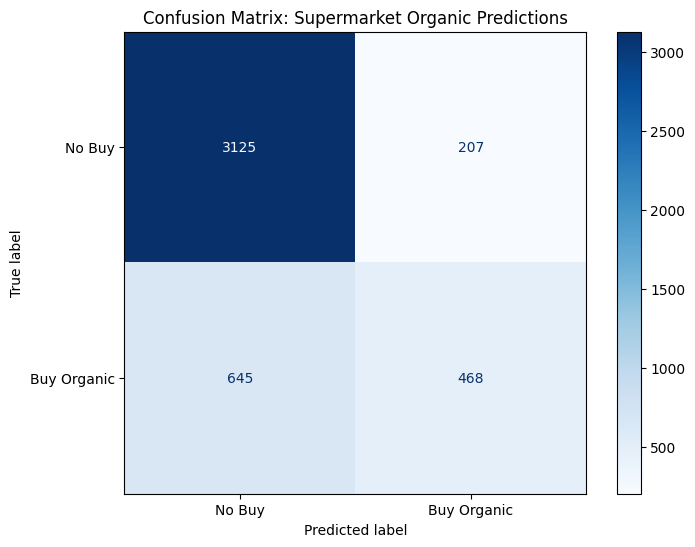

In [43]:
best_model = RandomForestClassifier(n_estimators=100, random_state=42)
best_model.fit(X_train, y_train)

# 2. Making predictions
y_pred = best_model.predict(X_test)

# 3. Dyspalying the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Buy', 'Buy Organic'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix: Supermarket Organic Predictions')
plt.show()

### Confusion Matrix

The confusion matrix provides a detailed breakdown of the model’s predictions by comparing actual and predicted values.

It includes:

True Positives: correctly predicted organic buyers
True Negatives: correctly predicted non-buyers
False Positives: incorrectly predicted buyers
False Negatives: missed actual buyers

This analysis helps identify the types of errors the model is making. In this scenario, the confusion matrix shows how well the model balances identifying buyers versus non-buyers. Depending on the distribution of errors, the model may be more prone to false positives or false negatives, which can have different business implications.

Understanding these errors is important for deciding whether further model tuning is needed, especially if one type of mistake is more costly than the other.

## Step 8 - Recommendation & Findings

### Typical Organic Buyer Profile

Based on the analysis, the typical organic buyer can be described as:

- Female
- Aged between 20 and 40
- Low to medium affluence score
- Short customer lifetime

This profile suggests that younger female customers with moderate purchasing power are more inclined towards organic products. However, the shorter customer lifetime may indicate lower long-term retention, which could be an area for further investigation.

Costumers with higher influence should be targeted with organic products promotions as per the analyses we can see that they are more likely to purchase this kind of products.

### Model Performance Comparison

Both models tested showed identical performance:

Logistic Regression Accuracy: 0.81
Random Forest Accuracy: 0.81

This suggests that increasing model complexity did not lead to improved predictive performance. Therefore, the simpler Logistic Regression model may be preferable due to its interpretability and lower computational cost.

### Cross-Validation Insights

The 10-fold cross-validation also produced an average accuracy of:

0.81

This consistency across training, testing, and validation indicates that the model generalizes well and is not significantly overfitting.

It also suggests that the data preprocessing and cleaning steps were effective, providing a stable foundation for model training, although there is still room for improvement.
While the results are consistent, further analysis is needed to evaluate class imbalance and the business impact of prediction errors.

In [45]:
print(cm)

[[3125  207]
 [ 645  468]]


### Error Analysis from Confusion Matrix

The confusion matrix was used to evaluate where the model makes the most mistakes.

From the matrix structure:

False Positives (FP): Non-buyers incorrectly predicted as buyers
False Negatives (FN): Buyers incorrectly predicted as non-buyers

The results show that the model makes significantly more errors in False Negatives (FN = 645) compared to False Positives (FP = 207). This indicates that the model struggles considerably more to correctly identify buyers.
This suggests that the model is biased towards predicting non-buyers, which reduces its effectiveness in detecting potential organic customers, particularly if buyers represent the minority class.

To improve performance, the following actions could be considered:

- Adjusting the classification threshold to better balance precision and recall.
- Collecting more balanced data to reduce class imbalance.
- Testing additional models or tuning hyperparameters to improve sensitivity to the target class.
- Additionally, improving data quality by encouraging more complete customer profiles could help the model learn more effectively. However, making all fields mandatory may introduce friction in the user experience and should be carefully balanced against potential data quality gains.

The model prioritizes overall accuracy at the expense of recall for buyers, which may not align with business objectives.

### References
Tierney, B. (2026) TU257: Fundamentals of Data Science Lecture Notes (Weeks 1-7). Technological University Dublin.

Pedregosa, F. et al. (2011) ‘Scikit-learn: Machine Learning in Python’, Journal of Machine Learning Research, 12, pp. 2825–2830. Available at: https://scikit-learn.org

James, G. et al. (2021) An Introduction to Statistical Learning. 2nd edn. Springer.